Dataset shape: (891, 13)


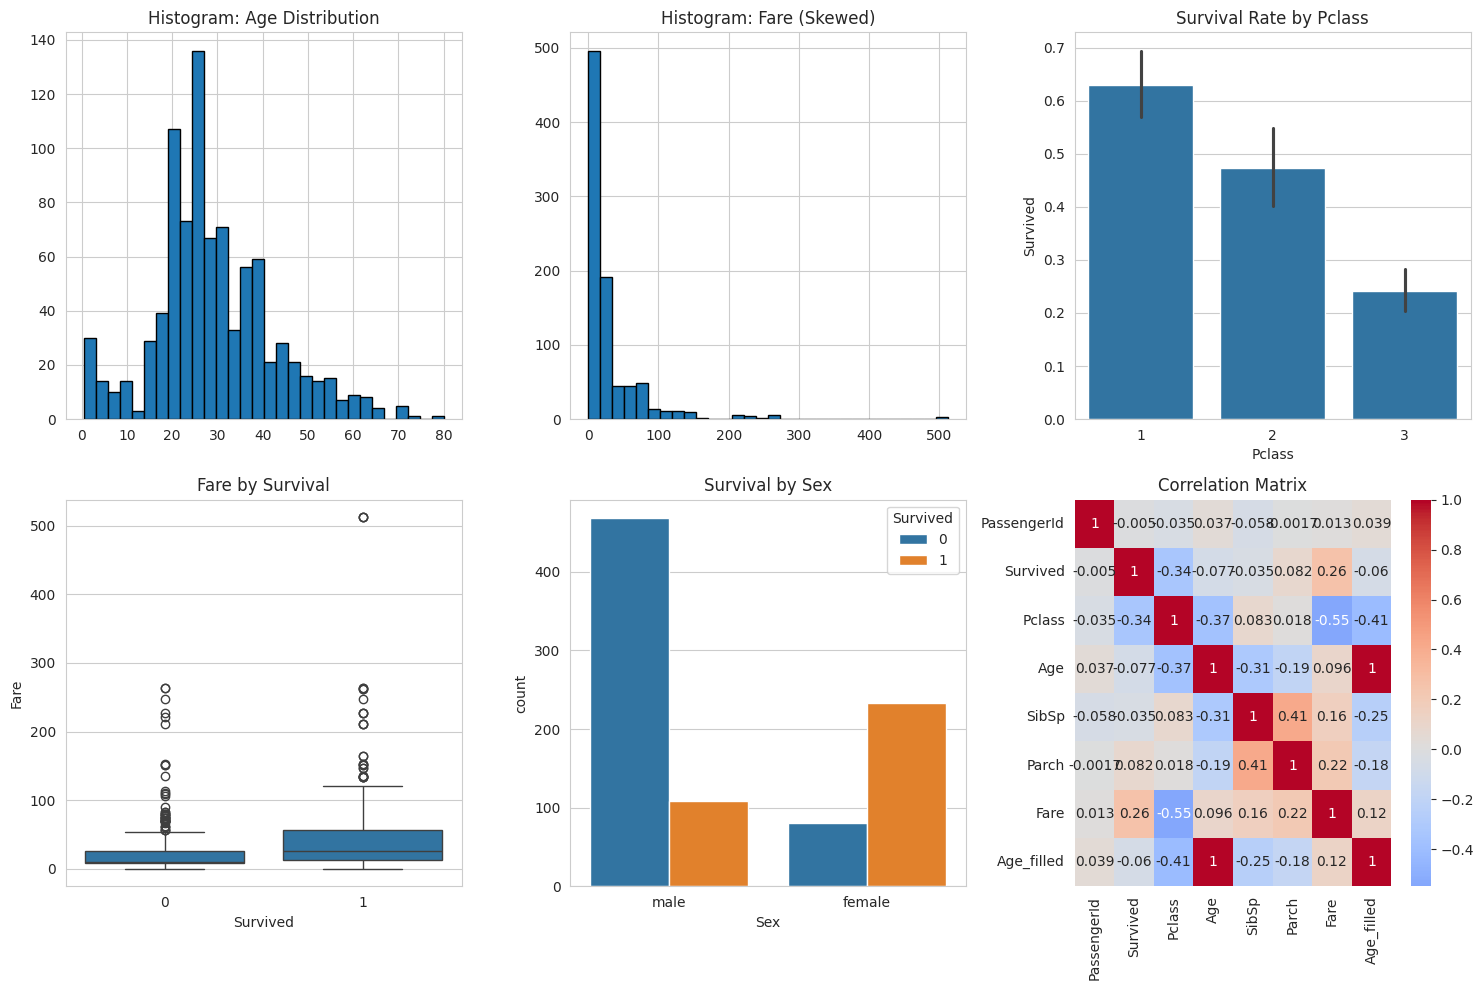

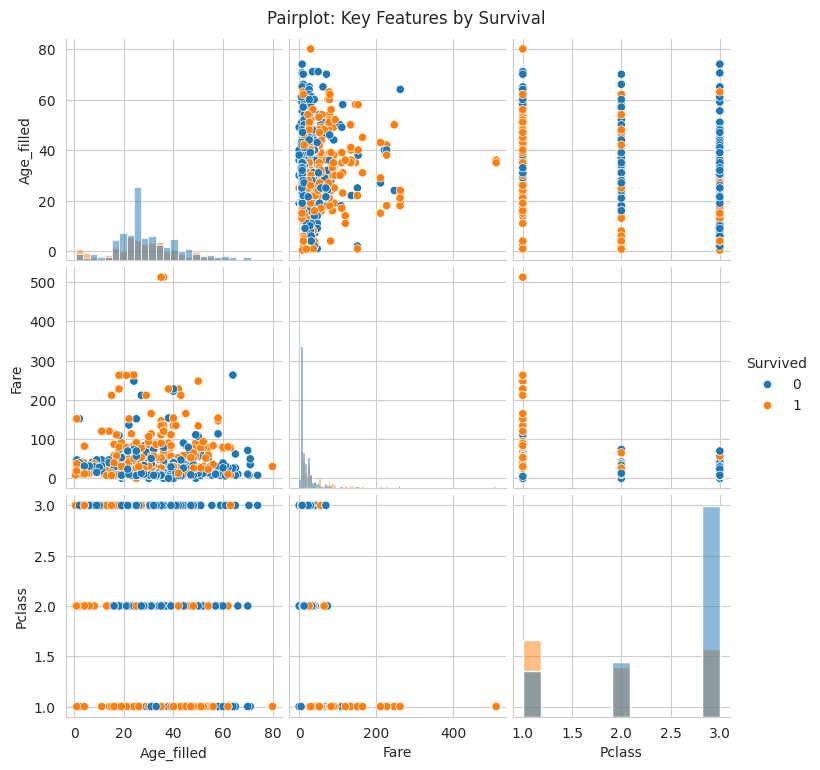

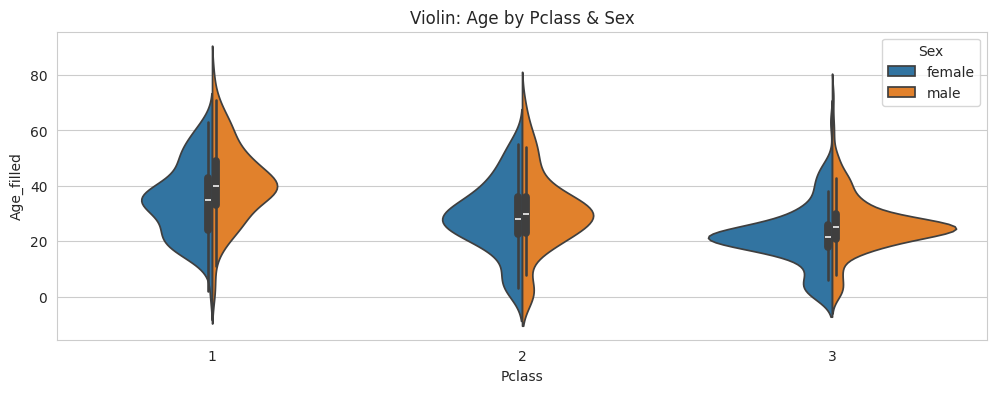

In [17]:
# Data Science Lab Assignment 8: Data Visualization w/ Matplotlib/Seaborn
# Dataset: Titanic (continuity Assignments 1-7) [web:21]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Age_filled'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

print("Dataset shape:", df.shape)

# 1. UNIVARIATE: Histograms (Matplotlib)
plt.figure(figsize=(15,10))

plt.subplot(2,3,1); plt.hist(df['Age_filled'], bins=30, edgecolor='black'); plt.title('Histogram: Age Distribution')
plt.subplot(2,3,2); plt.hist(df['Fare'], bins=30, edgecolor='black'); plt.title('Histogram: Fare (Skewed)')

# 2. BIVARIATE: Bar/Box (Seaborn)
plt.subplot(2,3,3); sns.barplot(x='Pclass', y='Survived', data=df); plt.title('Survival Rate by Pclass')
plt.subplot(2,3,4); sns.boxplot(x='Survived', y='Fare', data=df); plt.title('Fare by Survival')

# 3. CATEGORICAL: Countplot
plt.subplot(2,3,5); sns.countplot(x='Sex', hue='Survived', data=df); plt.title('Survival by Sex')

# 4. CORRELATION HEATMAP
plt.subplot(2,3,6); sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0); plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# 5. MULTIVARIATE PAIRPLOT (Seaborn)
sns.pairplot(df[['Age_filled','Fare','Pclass','Survived']], hue='Survived', diag_kind='hist')
plt.suptitle('Pairplot: Key Features by Survival', y=1.02)
plt.show()

# 6. ADVANCED: Violin (distribution shape)
plt.figure(figsize=(12,4))
sns.violinplot(x='Pclass', y='Age_filled', hue='Sex', split=True, data=df)
plt.title('Violin: Age by Pclass & Sex')
plt.show()
